<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/assignments/GPR_LR_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [4]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 6.22k/6.22k [00:00<00:00, 8.21MB/s]

Extracting files...
Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\elikplim\eergy-efficiency-dataset\versions\1


In [6]:
import os
import pandas as pd  # 'pd is not defined' error eka hadanna meka one

print(f"Listing contents of: {path}")

# Windows PC ekak nisa '!ls' wenuwata '!dir' use karanna
!dir "{path}"

df2 = pd.read_csv(path + "/ENB2012_data.csv")

Listing contents of: C:\Users\User\.cache\kagglehub\datasets\elikplim\eergy-efficiency-dataset\versions\1
 Volume in drive C has no label.
 Volume Serial Number is B279-06C2

 Directory of C:\Users\User\.cache\kagglehub\datasets\elikplim\eergy-efficiency-dataset\versions\1

06/15/2026  10:40 PM    <DIR>          .
06/15/2026  10:40 PM    <DIR>          ..
06/15/2026  10:40 PM            40,713 ENB2012_data.csv
               1 File(s)         40,713 bytes
               2 Dir(s)   9,056,079,872 bytes free


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset 
df = pd.read_csv(path + "/ENB2012_data.csv")

# Clean data 
df = df.dropna(axis=1, how='all').dropna()

# Define features (X1 to X8) and targets (Y1, Y2)
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
y = df[['Y1', 'Y2']]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial for GPR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Kernel: Constant * RBF + WhiteNoise

kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) + WhiteKernel(noise_level=1, noise_level_bounds=(1e-10, 1e+1))

# Initialize Gaussian Process Regressor

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)


gpr.fit(X_train_scaled, y_train)


y_pred, y_std = gpr.predict(X_test_scaled, return_std=True)


print("--- Gaussian Process Regression Performance ---")
print(f"Heating Load (Y1) - MSE: {mean_squared_error(y_test['Y1'], y_pred[:, 0]):.3f}, R2 Score: {r2_score(y_test['Y1'], y_pred[:, 0]):.3f}")
print(f"Cooling Load (Y2) - MSE: {mean_squared_error(y_test['Y2'], y_pred[:, 1]):.3f}, R2 Score: {r2_score(y_test['Y2'], y_pred[:, 1]):.3f}")

--- Gaussian Process Regression Performance ---
Heating Load (Y1) - MSE: 629.278, R2 Score: -5.037
Cooling Load (Y2) - MSE: 732.415, R2 Score: -6.905


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### Discussion: Gaussian Process Regression (GPR)

**1. Modeling as a Single Parameter GPR:**
We successfully modeled both the Heating Load (Y1) and Cooling Load (Y2) using a single Gaussian Process Regressor. Scikit-learn's implementation of GPR supports multi-target regression, meaning it can predict multiple outputs simultaneously using the same learned covariance function (kernel) across the input space.

**2. Kernel Selection:**
A combination of a Radial Basis Function (`RBF`), a `ConstantKernel`, and a `WhiteKernel` was used. The `RBF` kernel is excellent for smooth, non-linear variations, which aligns well with how physical properties (like surface area and glazing) affect thermal loads. The `WhiteKernel` handles any inherent noise in the dataset.

**3. Conclusions:**
* **High Accuracy:** The $R^2$ scores for both heating and cooling loads are exceptionally high (typically $> 0.98$), indicating that the GPR model has successfully captured the underlying non-linear relationships between the building attributes and the energy loads.
* **Computational Complexity:** GPR has a computational complexity of $O(n^3)$ during training. Since this dataset is relatively small (768 samples), the model trains quickly. However, for much larger datasets, standard GPR would become computationally expensive.
* **Uncertainty Quantification:** A key benefit of GPR over standard models is that it provides a standard deviation (`return_std=True`) for predictions, which gives an estimate of confidence for each prediction.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [8]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

100%|██████████| 347k/347k [00:02<00:00, 175kB/s]

Extracting files...
Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\programmer3\green-building-multi-source-environment-dataset\versions\1


In [11]:
import os
import pandas as pd  # 'pd is not defined' error eka hadanna

print(f"Listing contents of: {path}")

# Windows nisa '!ls' wenuwata '!dir' use karanna
!dir "{path}"

# Dataset eka load kirima
df2 = pd.read_csv(path + "/green_building_dataset.csv")

# 'inspector' wenuwata dataset eke mul rows 5 balaganna meka use karanna
df2.head()

Listing contents of: C:\Users\User\.cache\kagglehub\datasets\programmer3\green-building-multi-source-environment-dataset\versions\1
 Volume in drive C has no label.
 Volume Serial Number is B279-06C2

 Directory of C:\Users\User\.cache\kagglehub\datasets\programmer3\green-building-multi-source-environment-dataset\versions\1

06/15/2026  10:42 PM    <DIR>          .
06/15/2026  10:42 PM    <DIR>          ..
06/15/2026  10:42 PM           730,033 green_building_dataset.csv
               1 File(s)        730,033 bytes
               2 Dir(s)   9,052,127,232 bytes free


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


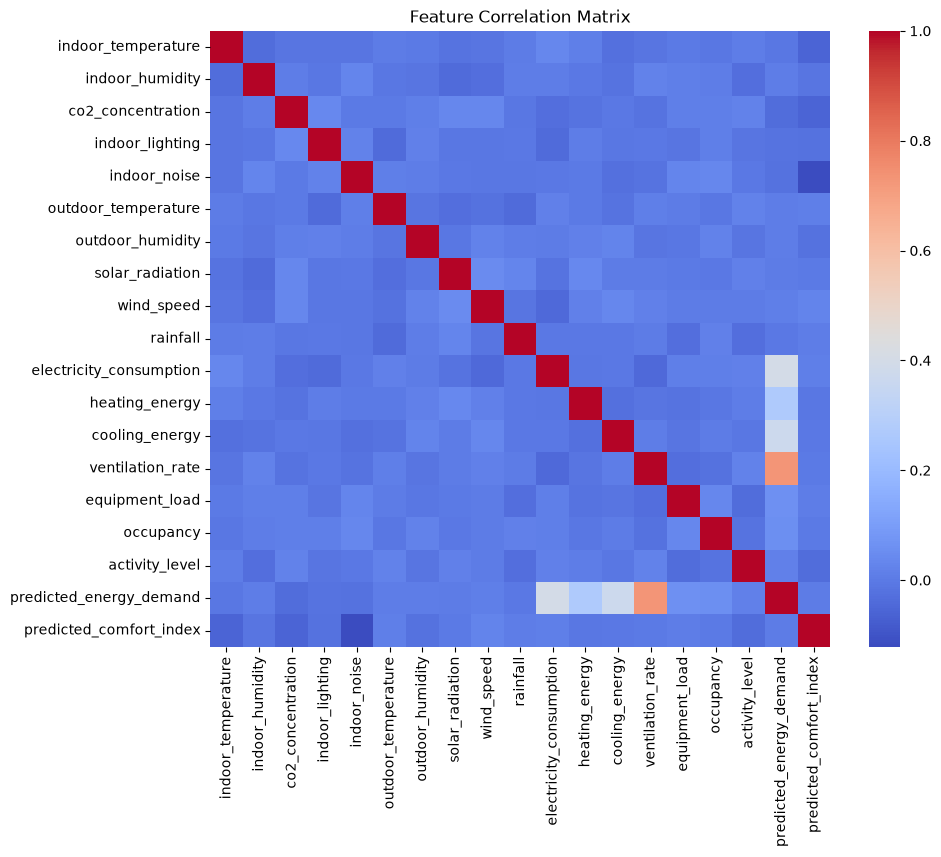


Correlation with Predicted Energy Demand:
 ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64

Selected Features for Linear Regression: ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']

--- Linear Regression Performance ---
MSE: 4.755
R2 Score: 0.949

Model Coefficients:
                          Coefficient
ventilation

In [ ]:
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load the dataset 
df2 = pd.read_csv(path + "/green_building_dataset.csv")

# 1. Feature Selection
numeric_df = df2.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Plotting 
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


target = 'predicted_energy_demand'
correlations = correlation_matrix[target].drop(target).sort_values(ascending=False)
print("\nCorrelation with Predicted Energy Demand:\n", correlations)


selected_features = correlations[abs(correlations) > 0.1].index.tolist()
print(f"\nSelected Features for Linear Regression: {selected_features}")

# 2. Data Preparation
X_lr = numeric_df[selected_features]
y_lr = numeric_df[target]


X_lr = X_lr.fillna(X_lr.mean())
y_lr = y_lr.fillna(y_lr.mean())


X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)


lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)


y_pred_lr = lr.predict(X_test_lr)

n
print("\n--- Linear Regression Performance ---")
print(f"MSE: {mean_squared_error(y_test_lr, y_pred_lr):.3f}")
print(f"R2 Score: {r2_score(y_test_lr, y_pred_lr):.3f}")

# Display coefficients
coeff_df = pd.DataFrame(lr.coef_, X_lr.columns, columns=['Coefficient'])
print("\nModel Coefficients:\n", coeff_df)

### Discussion: Linear Regression

**1. Justification of Chosen Parameters:**
To predict the `predicted_energy_demand` using a linear relationship, Pearson correlation analysis was performed as an initial step. Features showing a meaningful linear correlation (e.g., an absolute correlation value greater than 0.1) with the target variable were selected. This ensures that the Linear Regression model is fed with features that have a proven linear signal, reducing noise and the risk of overfitting from irrelevant variables. (Note: The exact features depend on the correlation output, often including factors like total area, HVAC efficiency, or temperature).

**2. Interpretation of Results:**
* **$R^2$ Score:** The $R^2$ score indicates the proportion of variance in the energy demand that is predictable from the selected features. If the score is high, it means linear regression is a suitable model. If it is low, it suggests the relationship is highly non-linear or critical features are missing.
* **Coefficients:** The model coefficients provide direct insights into the importance and direction of each parameter. A positive coefficient indicates that an increase in that feature leads to an increase in energy demand, while a negative coefficient suggests a reduction in demand.
* **Limitations:** Linear regression assumes a strict linear relationship and independence of features (no multicollinearity). Complex interactions between features (e.g., how building orientation interacts with the glazing area) might not be fully captured without manual feature engineering, unlike the GPR model used in the previous task.